In [23]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [332]:
df = pd.read_table("data/data/unknown/Gaia DR2 5536809162106730112.txt",delimiter=' ',names=['time','flux','err'])

In [333]:
df

,time,flux,err
0,2229.000848,1.010277,0.011362
1,2229.002237,0.994615,0.011333
2,2229.003626,0.989459,0.011339
3,2229.005015,0.980278,0.011285
4,2229.006404,1.003518,0.011296
...,...,...,...
16696,2254.062077,1.011241,0.009741
16697,2254.063466,1.000062,0.009746
16698,2254.064854,1.005924,0.009740
16699,2254.066243,0.997010,0.009717


In [423]:
times = np.array(df['time'])
fluxes = np.array(df['flux'])

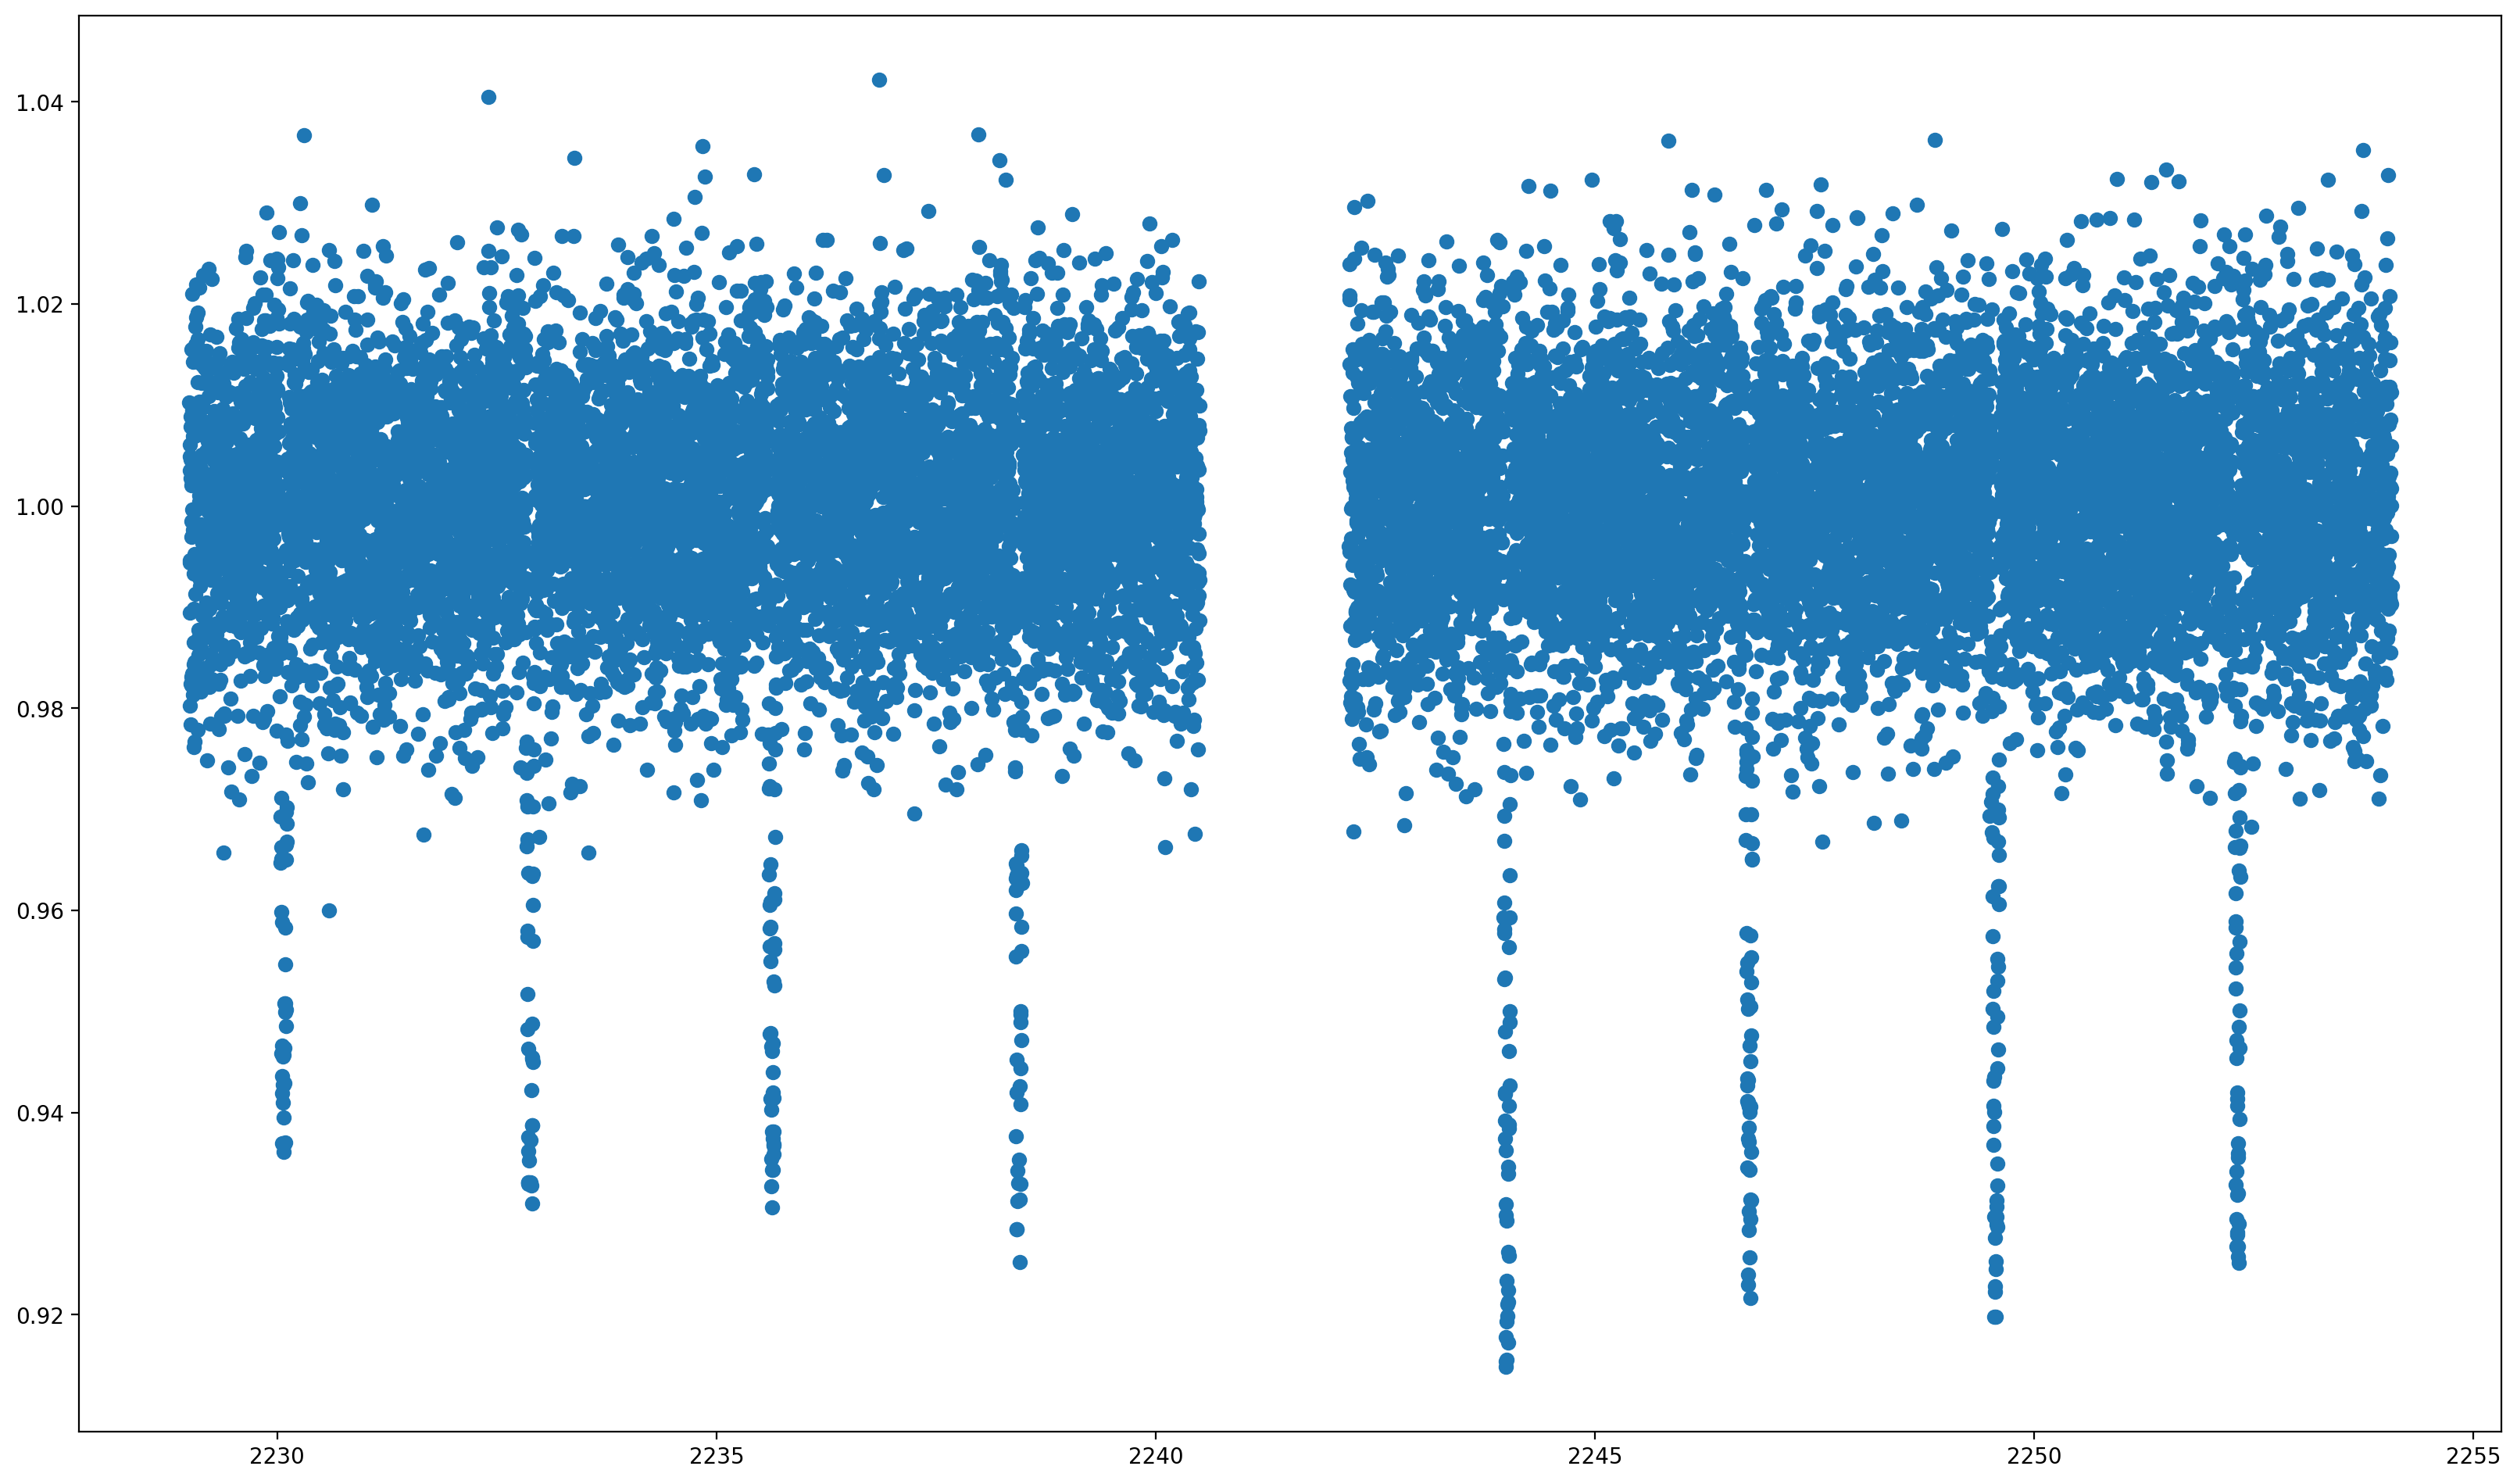

In [359]:
fig,ax = plt.subplots(figsize=(20,12),dpi=200)
plt.scatter(times,df['flux'])

In [629]:
fluxes = np.array(df['flux'])
len(fluxes) / 2**5

521.90625

In [425]:
times = np.array(df['time'])
fluxes = np.array(df['flux'])
k = (times[-1]-times[0])/len(times)
k

0.0015009151499540167

In [135]:
def BF_fold(data_in, m, n, k_init=3, p_min=None):
  '''
  Function: BF_fold
  -----------------
  This is the `brute-force' routine. For an input data of dimensions m*2^n
  it produces a set of folds, produced from smaller subsections of the data,   
  of length m*2^k_init.

  The requirement on the length of the input light curve is only for 
  convenience and simplification of the code. This is generally not a 
  requirement, as brute force can deal with different lengths and 
  irregular sampling. 

  Inupt: data_in - array (1D) of length m*2^n that contains the lightcurve
         m, n    - integers, the size of the input data
         k_init  - integer (see above)
         p_min   - integer, larger or equal to m. The minimal period, so that
                   folds will be generated in the interval [p_min, p_min+1]
                   
  Output:  data_out - a matrix of folds, of level k_init.
           n_prime  - the effective size of the matrix, in terms of the 
                      number of trial periods.
  '''
  # Initialize data matrix and period vector
  # -----------------------------------------
  if p_min is None:
    # The default is to search between m and m+1
    p_min, n_prime, data = m, n, data_in
  else:
    # But, we've also enabled a search between m+k and m+k+1 for 
    # positive integer value of k
    n_prime       = int(np.ceil(np.log2((m/p_min)*2**n)))
    data          = (np.zeros(p_min*2**n))
    data[:m*2**n] = data_in

  # Arrange the output data matrix 
  data_out = (np.zeros_like(data[:m*2**n_prime])).reshape((2**n_prime,m))
  periods  = np.array([p_min + x/(2**k_init-1) for x in np.arange(2**k_init)])
  
  # Cut data sections, and fold them according to the period vector
  # ---------------------------------------------------------------
  row_index    = 0
  sect_len     = p_min*2**k_init
  data_indices = np.arange(sect_len)
  
  # Iterate over sections
  # ---------------------
  for k in np.arange(p_min*2**n_prime//sect_len):
    data_section = data[k*sect_len : (k+1)*sect_len]

  # And for each section generate and store the folded lightcurves
  # --------------------------------------------------------------
    for p in periods:
      fold_indices = np.floor((data_indices%p)*m/p)
      fold         = np.array(
          [np.sum(data_section[np.argwhere(fold_indices==phi)]) 
          for phi in np.arange(m)]
          )
      data_out[row_index, :] = fold
      row_index += 1

  return data_out, n_prime

In [653]:
m, n        = int(2.78 / k), 3
# m, n = 131, 7
period, t0  = 2.78/k, (2230 - times[0]) / k
noise_level = 1e-1
width       = 15

In [654]:
m * 2**n - len(fluxes)

14815

(0.35, 0.45)

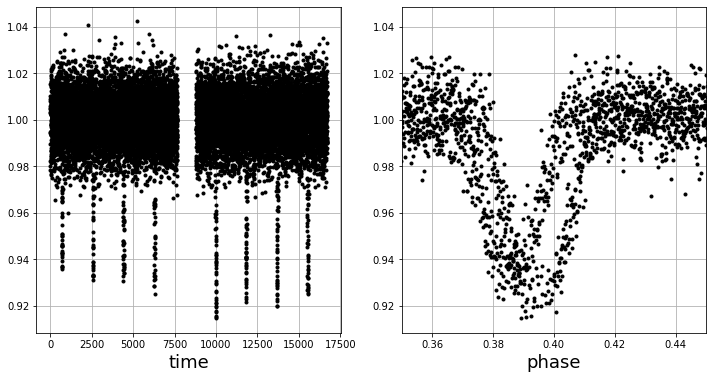

In [655]:
fluxes = np.array(df['flux'])
# fluxes = np.resize(fluxes,(1,m*2**n))
# fig,ax = plt.subplots(figsize=(10,10))
# plt.imshow(new_fluxes)
times = np.array(df['time'])
times = (times -times[0]) // k
# times = np.arange(len(times_raw))

# Print the lightcurve and the correct fold:
# -----------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12,6))
_ = ax[0].plot(times, fluxes, '.k')
_ = ax[1].plot(times%(period)/m, fluxes, '.k')
_ = ax[0].set_xlabel(r'time', fontsize=18)
_ = ax[1].set_xlabel(r'phase', fontsize=18)
ax[0].grid(); ax[1].grid()
plt.xlim(0.35, 0.45)

In [656]:
fluxes = np.array(df['flux'])
fluxes = np.resize(fluxes,(1,m*2**n)) - 1

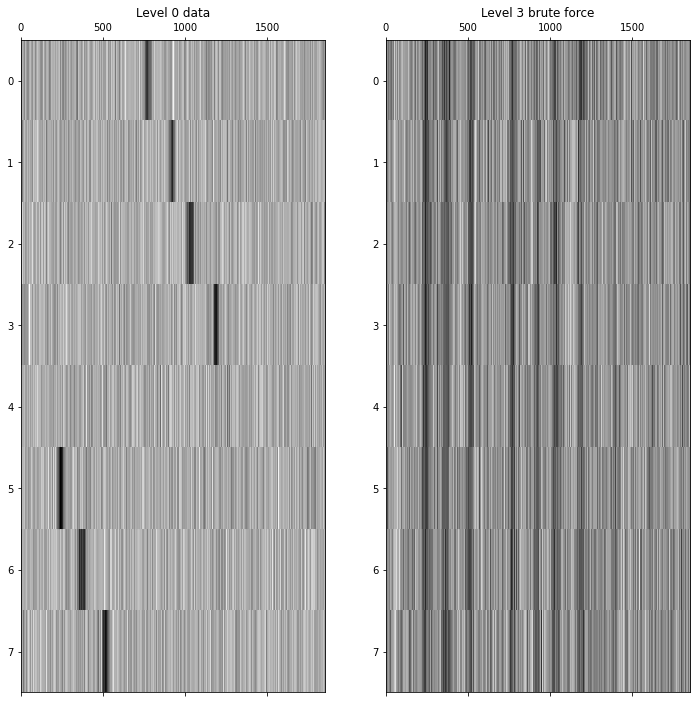

In [657]:
# Set the initialization level to 2 and the minimal period
# --------------------------------------------------------
k_init               = 3
p_min                = int(np.floor(period))

# Start with a brute force folding
# --------------------------------
# We also generate the counts matrix, in order to calculate the BLS score.
flux_BFfold, n_prime = BF_fold(fluxes, m,n, k_init, p_min=p_min)
count_BFfold, _      = BF_fold(np.ones_like(fluxes), m,n, k_init, p_min=p_min)

# Plot the brute force folded data along with the zeroth level
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12,12))
plt.set_cmap('gray')
_ = ax[0].matshow(fluxes.reshape((2**n,m)),aspect='auto')
_ = ax[0].set_title('Level 0 data')
_ = ax[1].matshow(flux_BFfold,aspect='auto')
_ = ax[1].set_title('Level ' + str(k_init) + ' brute force')

In [199]:
def FFA_step(data, l, m, n):
  '''
  Function: FFA_step
  ------------------
  This routine runs a single FFA step, from level (l-1) to level (l).
  The data dimensions are given by m and n, such that the input data
  is of size m X 2^n 
  
  Input: data    - numpy array of m X 2^n
         l, m, n - integers (see text above)
  
  Output: data_new - numpy array of m X 2^n
  '''
  
  # Initialize output matrix
  # ------------------------
  data_new = np.zeros(data.shape)

  # Initialize FFA indices
  # ----------------------
  phi      = np.arange(m, dtype=int)
  i_prime  = np.arange(2**(n-l), dtype=int)
  p        = np.arange(2**l, dtype=int)

  # Initialize the phase shift vector
  # ---------------------------------
  S = np.array([0,1], dtype=int)
  for ltmp in np.arange(1,l):
    Stmp = S+2**(ltmp-1)*np.ones_like(S, dtype=int)  
    S    = np.concatenate((S, Stmp))

  # Fold
  # ----
  for pp in p:
    for ii in i_prime:
      i   = int(2**l * ii + pp)
      mu  = int(2**l * ii + np.floor(pp/2))
      nu  = int(2**l * ii + np.floor(pp/2) + 2**(l-1))

      data_new[i, phi] = data[mu, phi] + data[nu, np.mod(phi + S[pp], m)]

  return data_new

ValueError: Integers to negative integer powers are not allowed.

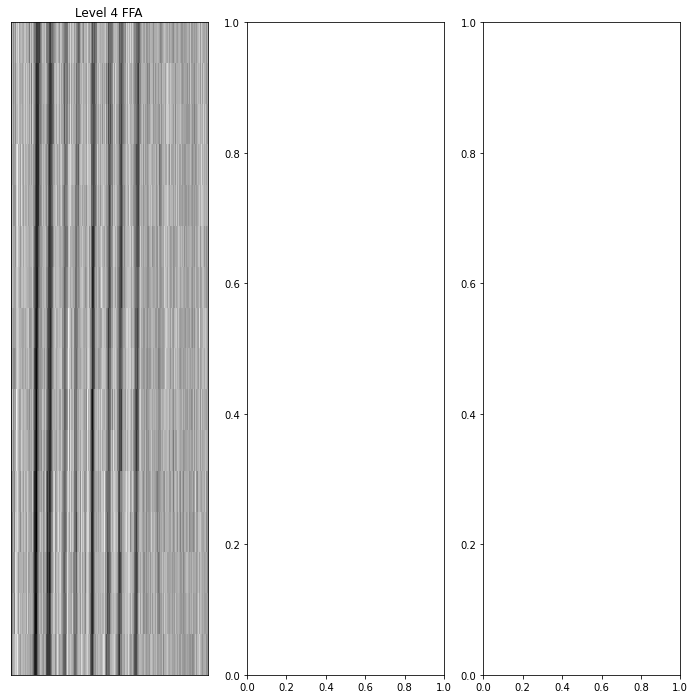

In [639]:
fig, axs = plt.subplots(1, n-k_init, figsize=(12,12))
plt.set_cmap('gray')

# Run FFA and plot the matrix on each step
# We also generate the count matrix, for the fbls calculation
F = flux_BFfold
N = count_BFfold
fig_count = 0

for ll in np.arange(k_init+1, n+1):
  if ll > k_init:
    F = FFA_step(F,ll,m,n_prime)
    N = FFA_step(N,ll,m,n_prime)
    axs[fig_count].matshow(F,aspect='auto')
    axs[fig_count].set_title('Level ' + str(ll) + ' FFA')
    axs[fig_count].get_xaxis().set_ticks([])
    axs[fig_count].get_yaxis().set_ticks([])
    fig_count += 1
_ = axs[-1].plot(np.array([0,m-1]),np.array([period%p_min,period%p_min])*(2**(n)-1)*(2**(n_prime-n)),'-r')

In [521]:
def fBLS(F, N, max_width,m, n, p_min):
  '''
  Function: fBLS
  --------------
  This function calculates the BLS score for the set of folded lightcurves. 
    
  Input: F, N      - the folded flux and counts matrix, respectively.
         max_width - the maximal number of bins in transit.
         m, n      - the integer representing the matrix dimensions. 
         p_min     - the minimal period, so that the search is in the range [p_min, p_min + 1]
  
  Output: Score, Period - the BLS score and period grid vectors, respectively.
  '''
  # Calculate the s value (see equation (3) in the BLS paper):
  S = F/(m*2**n)
  twiceS = np.concatenate((S, S[:, 0:max_width+1]), axis=1)

  # Calculate the r value (see Section (2) in the BLS paper):
  R = N/(m*2**n)
  twiceR = np.concatenate((R, R[:, 0:max_width+1]), axis=1)

  # Initialize data structures, according to BLS 2002 convention
  s = np.zeros_like(S)
  r = np.zeros_like(R)

  # Convolve with a box. Define a rectangle pulse with a given window_length
  Score = np.zeros(F.shape[0])
  for i in np.arange(max_width):
    s += twiceS[:, i:i+m]
    r += twiceR[:, i:i+m]

    # SR is the score defined in the BLS paper: SR = (s**2/(r*(1-r)))**0.5
    SR = np.divide(np.abs(s), np.sqrt(r*(1-r)))
    SRmax = np.max(SR, axis=1)
    new_score_ind = SRmax > Score
    Score[new_score_ind] = SRmax[new_score_ind]
    
  n_prime = np.log2(m/p_min*2**n)
  Period  = p_min + np.arange(2**n)/(2**n_prime-1) 
  
  return Score, Period

ValueError: x and y must have same first dimension, but have shapes (64,) and (16,)

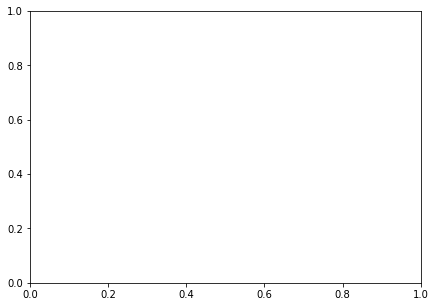

In [640]:
s, p = fBLS(F, N, 35,m, n, p_min)

plt.figure(figsize=(7,5))
plt.plot(p, s,'k')
plt.grid()
_ = plt.plot([period, period],[0, np.max(s)],'r')
_ = plt.xlabel(r'Period', fontsize=18)
_ = plt.ylabel(r'SR', fontsize=18)